# Dark Condition — Baseline vs Fine-tuned Comparison

This notebook implements the **Condition A vs Condition B** evaluation defined in Chapter 3.6.

- **Condition A (Baseline):** `yolov8n.pt` — pretrained only, no fine-tuning
- **Condition B (Fine-tuned):** `best.pt` — fine-tuned on LLVIP dataset

Both models are tested on the same dark/night video across **3 confidence thresholds** (0.25, 0.35, 0.50).
Threshold 0.35 is the F1-optimal value identified from the BoxF1_curve generated during training.

### Outputs
1. Summary metrics table (avg detections/frame, improvement %)
2. Per-frame detection count chart (line plot)
3. Side-by-side frame samples (baseline vs fine-tuned)
4. Saved annotated video (optional)

## 0) Dependencies

In [ ]:
# Run once if needed
# !pip install -q ultralytics opencv-python numpy pandas matplotlib

## 1) Configuration — Edit these paths

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ultralytics import YOLO

# ─────────────────────────────────────────────
# EDIT THESE
# ─────────────────────────────────────────────
VIDEO_PATH       = '../video/night.avi'          # dark/night test video
BASELINE_WEIGHTS = 'yolov8n.pt'                  # original pretrained model
FINETUNED_WEIGHTS = 'runs/darkCondition_yolo/runs/yolov8n_llvip_person/weights/best.pt'
OUTPUT_DIR = 'outputs/dark_comparison'           # where results are saved
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Threshold sweep — F1-optimal is 0.35 (from BoxF1_curve)
THRESHOLDS = [0.25, 0.35, 0.50]

# Set to True to save annotated side-by-side video (slower)
SAVE_VIDEO = True

# Max frames to process (None = full video, set e.g. 500 for quick test)
MAX_FRAMES = None

print('VIDEO_PATH       :', VIDEO_PATH)
print('BASELINE_WEIGHTS :', BASELINE_WEIGHTS)
print('FINETUNED_WEIGHTS:', FINETUNED_WEIGHTS)
print('THRESHOLDS       :', THRESHOLDS)

# Verify files exist
for p in [VIDEO_PATH, BASELINE_WEIGHTS, FINETUNED_WEIGHTS]:
    status = '✅' if os.path.exists(p) else '❌ NOT FOUND'
    print(f'  {status}  {p}')

VIDEO_PATH       : ../video/night.avi
BASELINE_WEIGHTS : yolov8n.pt
FINETUNED_WEIGHTS: runs/darkCondition_yolo/runs/yolov8n_llvip_person/weights/best.pt
THRESHOLDS       : [0.25, 0.35, 0.5]
  ✅  ../video/night.avi
  ✅  yolov8n.pt
  ✅  runs/darkCondition_yolo/runs/yolov8n_llvip_person/weights/best.pt


## 2) Core Detection Runner

Runs a YOLO model on every frame and records per-frame detection counts and bounding boxes.

In [2]:
def run_detection(video_path, weights, conf_threshold, max_frames=None):
    """
    Runs YOLO person detection on a video.

    Returns:
        records  : list of dicts  {frame_id, count, boxes[(x1,y1,x2,y2,conf)]}
        raw_frames: list of original BGR frames (for visualisation)
    """
    model = YOLO(weights)
    cap   = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        raise RuntimeError(f'Cannot open video: {video_path}')

    records    = []
    raw_frames = []
    frame_id   = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if max_frames is not None and frame_id >= max_frames:
            break

        results = model(
            frame,
            conf=conf_threshold,
            classes=[0],       # person only
            verbose=False
        )[0]

        boxes = []
        if results.boxes is not None:
            for b in results.boxes:
                x1, y1, x2, y2 = b.xyxy[0].cpu().numpy().astype(int)
                conf = float(b.conf[0].cpu().numpy())
                boxes.append((x1, y1, x2, y2, conf))

        records.append({
            'frame_id': frame_id,
            'count'   : len(boxes),
            'boxes'   : boxes
        })
        raw_frames.append(frame.copy())
        frame_id += 1

    cap.release()
    print(f'  Done: {frame_id} frames | model={os.path.basename(weights)} | conf={conf_threshold}')
    return records, raw_frames

## 3) Run Both Models Across All Thresholds

This cell is the main sweep. It runs baseline and fine-tuned models at each threshold and stores all results.

In [3]:
# results_store[thresh][model_name] = (records, raw_frames)
results_store = {}

for thresh in THRESHOLDS:
    print(f'\n── Threshold: {thresh} ──')
    results_store[thresh] = {}

    print('  [Baseline]')
    rec_b, frames_b = run_detection(
        VIDEO_PATH, BASELINE_WEIGHTS, thresh, MAX_FRAMES
    )
    results_store[thresh]['baseline'] = (rec_b, frames_b)

    print('  [Fine-tuned]')
    rec_f, frames_f = run_detection(
        VIDEO_PATH, FINETUNED_WEIGHTS, thresh, MAX_FRAMES
    )
    results_store[thresh]['finetuned'] = (rec_f, frames_f)

print('\n✅ All sweeps complete.')


── Threshold: 0.25 ──
  [Baseline]
  Done: 565 frames | model=yolov8n.pt | conf=0.25
  [Fine-tuned]
  Done: 565 frames | model=best.pt | conf=0.25

── Threshold: 0.35 ──
  [Baseline]
  Done: 565 frames | model=yolov8n.pt | conf=0.35
  [Fine-tuned]
  Done: 565 frames | model=best.pt | conf=0.35

── Threshold: 0.5 ──
  [Baseline]
  Done: 565 frames | model=yolov8n.pt | conf=0.5
  [Fine-tuned]
  Done: 565 frames | model=best.pt | conf=0.5

✅ All sweeps complete.


## 4) Summary Metrics Table

Avg detections per frame, zero-detection frames (missed), and improvement % for each threshold.

In [4]:
rows = []

for thresh in THRESHOLDS:
    for model_name in ['baseline', 'finetuned']:
        records, _ = results_store[thresh][model_name]
        counts = [r['count'] for r in records]
        rows.append({
            'Threshold'          : thresh,
            'Model'              : 'Baseline (yolov8n.pt)' if model_name == 'baseline'
                                   else 'Fine-tuned (best.pt)',
            'Avg Det/Frame'      : round(np.mean(counts), 3),
            'Max Det/Frame'      : int(np.max(counts)),
            'Zero-Det Frames'    : int(np.sum(np.array(counts) == 0)),
            'Zero-Det Frames (%)':
                round(100 * np.sum(np.array(counts) == 0) / len(counts), 1),
            'Total Detections'   : int(np.sum(counts)),
        })

df_summary = pd.DataFrame(rows)

# Add improvement % column
improvement_rows = []
for thresh in THRESHOLDS:
    base = df_summary[
        (df_summary['Threshold'] == thresh) &
        (df_summary['Model'].str.contains('Baseline'))
    ]['Avg Det/Frame'].values[0]
    fine = df_summary[
        (df_summary['Threshold'] == thresh) &
        (df_summary['Model'].str.contains('Fine'))
    ]['Avg Det/Frame'].values[0]
    pct = round((fine - base) / max(base, 1e-6) * 100, 1)
    improvement_rows.append({'Threshold': thresh, 'Improvement %': pct})

df_improvement = pd.DataFrame(improvement_rows)

print('=== Per-Model Summary ===')
display(df_summary)

print('\n=== Improvement of Fine-tuned over Baseline (Avg Det/Frame) ===')
display(df_improvement)

# Save to CSV
df_summary.to_csv(os.path.join(OUTPUT_DIR, 'comparison_summary.csv'), index=False)
df_improvement.to_csv(os.path.join(OUTPUT_DIR, 'improvement_summary.csv'), index=False)
print('\nSaved CSVs to:', OUTPUT_DIR)

=== Per-Model Summary ===


,Threshold,Model,Avg Det/Frame,Max Det/Frame,Zero-Det Frames,Zero-Det Frames (%),Total Detections
0,0.25,Baseline (yolov8n.pt),0.890,2,76,13.5,503
1,0.25,Fine-tuned (best.pt),0.961,2,34,6.0,543
2,0.35,Baseline (yolov8n.pt),0.848,2,92,16.3,479
3,0.35,Fine-tuned (best.pt),0.942,2,42,7.4,532
4,0.50,Baseline (yolov8n.pt),0.784,2,123,21.8,443
5,0.50,Fine-tuned (best.pt),0.876,2,72,12.7,495



=== Improvement of Fine-tuned over Baseline (Avg Det/Frame) ===


,Threshold,Improvement %
0,0.25,8.0
1,0.35,11.1
2,0.50,11.7



Saved CSVs to: outputs/dark_comparison


## 5) Per-Frame Detection Count Chart

Line plot showing baseline vs fine-tuned detection count per frame for each threshold.
The fine-tuned model should show more detections (higher line) on dark frames.

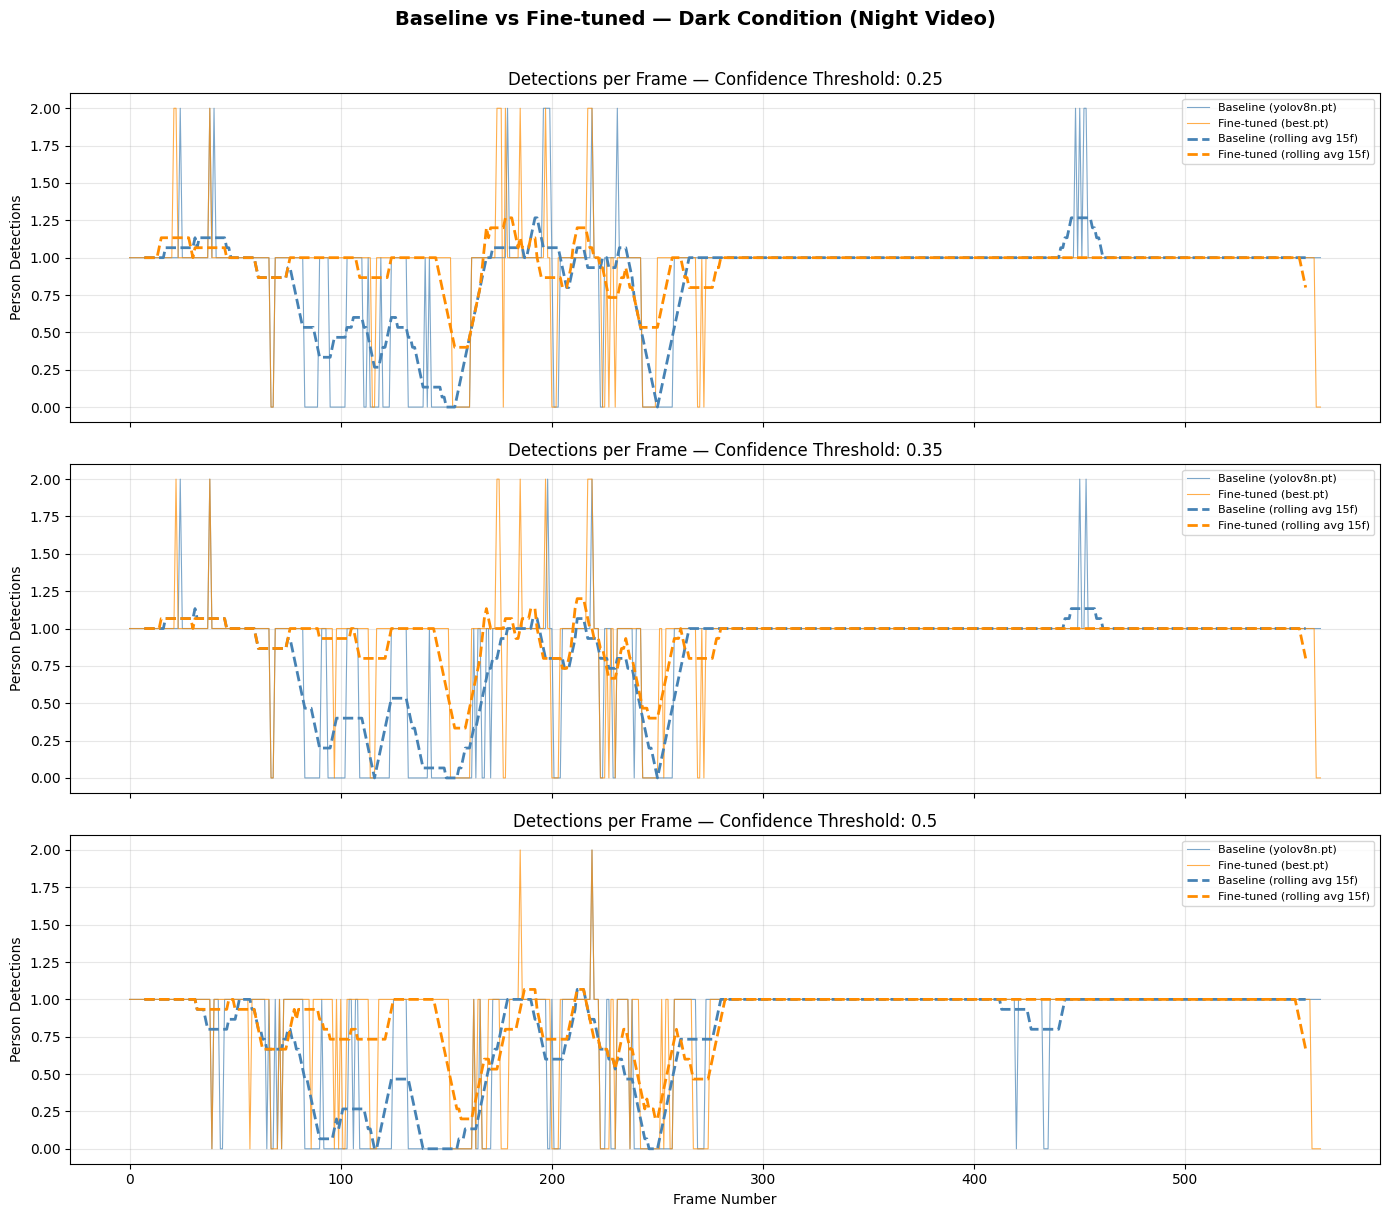

Saved chart to: outputs/dark_comparison\detection_count_chart.png


In [5]:
fig, axes = plt.subplots(len(THRESHOLDS), 1,
                          figsize=(14, 4 * len(THRESHOLDS)),
                          sharex=True)

if len(THRESHOLDS) == 1:
    axes = [axes]

for ax, thresh in zip(axes, THRESHOLDS):
    rec_b, _ = results_store[thresh]['baseline']
    rec_f, _ = results_store[thresh]['finetuned']

    frame_ids = [r['frame_id'] for r in rec_b]
    counts_b  = [r['count']    for r in rec_b]
    counts_f  = [r['count']    for r in rec_f]

    ax.plot(frame_ids, counts_b, color='steelblue',  alpha=0.7,
            linewidth=0.8, label='Baseline (yolov8n.pt)')
    ax.plot(frame_ids, counts_f, color='darkorange', alpha=0.7,
            linewidth=0.8, label='Fine-tuned (best.pt)')

    # Rolling average (window=15 frames) to show trend clearly
    window = 15
    if len(counts_b) > window:
        roll_b = pd.Series(counts_b).rolling(window, center=True).mean()
        roll_f = pd.Series(counts_f).rolling(window, center=True).mean()
        ax.plot(frame_ids, roll_b, color='steelblue',  linewidth=2.0,
                linestyle='--', label=f'Baseline (rolling avg {window}f)')
        ax.plot(frame_ids, roll_f, color='darkorange', linewidth=2.0,
                linestyle='--', label=f'Fine-tuned (rolling avg {window}f)')

    ax.set_title(f'Detections per Frame — Confidence Threshold: {thresh}',
                 fontsize=12)
    ax.set_ylabel('Person Detections')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('Frame Number')
plt.suptitle(
    'Baseline vs Fine-tuned — Dark Condition (Night Video)',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()

chart_path = os.path.join(OUTPUT_DIR, 'detection_count_chart.png')
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved chart to:', chart_path)

## 6) Side-by-Side Frame Samples

Picks frames where the models disagree the most — i.e. fine-tuned detected more persons
than baseline. These are the most informative frames to show in the report.

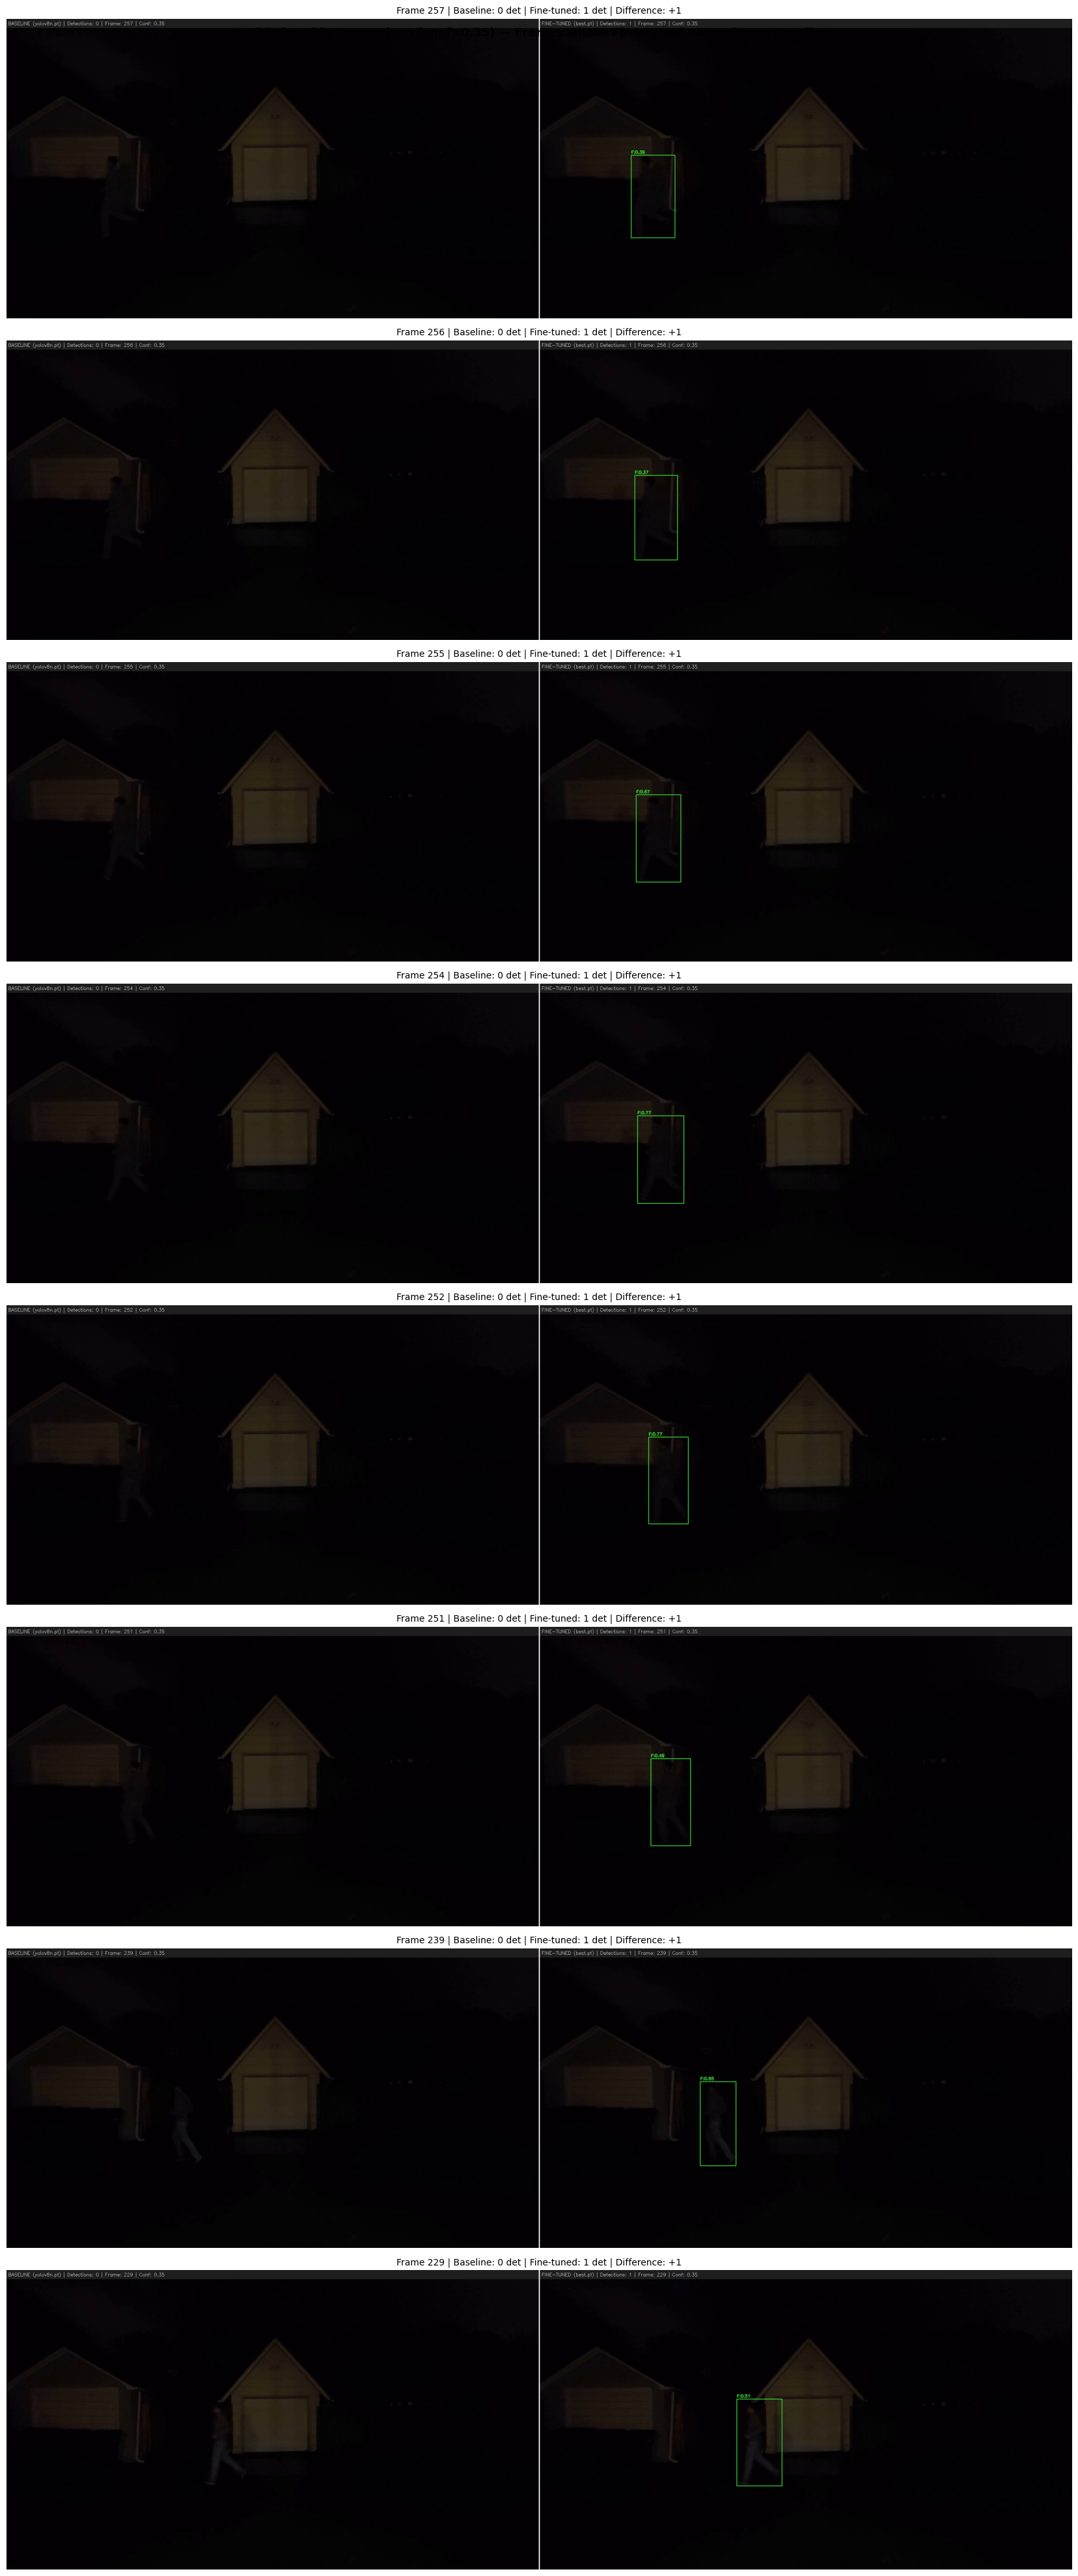

Saved sample image to: outputs/dark_comparison\side_by_side_samples.png


In [6]:
def annotate_frame(frame, boxes, color, label_prefix=''):
    """Draw bounding boxes on a copy of the frame."""
    out = frame.copy()
    for (x1, y1, x2, y2, conf) in boxes:
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
        txt = f'{label_prefix}{conf:.2f}'
        cv2.putText(out, txt, (x1, max(0, y1 - 6)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    return out


def make_side_by_side(frame_b, frame_f, frame_id, thresh,
                      count_b, count_f):
    """Stack baseline and finetuned frames side by side with labels."""
    h = max(frame_b.shape[0], frame_f.shape[0])
    w = frame_b.shape[1]

    canvas_b = np.zeros((h, w, 3), dtype=np.uint8)
    canvas_f = np.zeros((h, w, 3), dtype=np.uint8)
    canvas_b[:frame_b.shape[0], :w] = frame_b
    canvas_f[:frame_f.shape[0], :w] = frame_f

    # Banner labels
    for canvas, label, count in [
        (canvas_b, 'BASELINE (yolov8n.pt)', count_b),
        (canvas_f, 'FINE-TUNED (best.pt)',  count_f)
    ]:
        cv2.rectangle(canvas, (0, 0), (w, 32), (30, 30, 30), -1)
        cv2.putText(canvas,
                    f'{label} | Detections: {count} | Frame: {frame_id} | Conf: {thresh}',
                    (6, 22), cv2.FONT_HERSHEY_SIMPLEX, 0.55,
                    (255, 255, 255), 1)

    divider = np.full((h, 4, 3), 255, dtype=np.uint8)
    return np.hstack([canvas_b, divider, canvas_f])


# Use threshold 0.35 (F1-optimal) for the visual sample
SAMPLE_THRESH  = 0.35
N_SAMPLES      = 8      # number of sample frames to show
COLOR_BASELINE = (255, 100, 50)   # blue-ish (BGR)
COLOR_FINETUNED= (50, 200, 50)    # green (BGR)

rec_b, frames_b = results_store[SAMPLE_THRESH]['baseline']
rec_f, frames_f = results_store[SAMPLE_THRESH]['finetuned']

# Find frames where finetuned detects MORE than baseline (most interesting)
diffs = [
    (rec_f[i]['count'] - rec_b[i]['count'], i)
    for i in range(len(rec_b))
]
diffs.sort(reverse=True)   # largest improvement first
sample_indices = [idx for _, idx in diffs[:N_SAMPLES]]

# Also include a few frames where both detected something (balanced view)
both_detected = [
    i for i in range(len(rec_b))
    if rec_b[i]['count'] > 0 and rec_f[i]['count'] > 0
]
if both_detected:
    sample_indices += both_detected[:max(0, N_SAMPLES - len(sample_indices))]
sample_indices = list(dict.fromkeys(sample_indices))[:N_SAMPLES]  # deduplicate

fig, axes = plt.subplots(N_SAMPLES, 1,
                          figsize=(18, 5 * N_SAMPLES))
if N_SAMPLES == 1:
    axes = [axes]

for ax, fidx in zip(axes, sample_indices):
    ann_b = annotate_frame(
        frames_b[fidx], rec_b[fidx]['boxes'],
        COLOR_BASELINE, label_prefix='B:')
    ann_f = annotate_frame(
        frames_f[fidx], rec_f[fidx]['boxes'],
        COLOR_FINETUNED, label_prefix='F:')

    combined = make_side_by_side(
        cv2.cvtColor(ann_b, cv2.COLOR_BGR2RGB),
        cv2.cvtColor(ann_f, cv2.COLOR_BGR2RGB),
        fidx, SAMPLE_THRESH,
        rec_b[fidx]['count'], rec_f[fidx]['count']
    )
    ax.imshow(combined)
    ax.axis('off')
    diff = rec_f[fidx]['count'] - rec_b[fidx]['count']
    diff_str = f'+{diff}' if diff >= 0 else str(diff)
    ax.set_title(
        f'Frame {fidx} | '
        f'Baseline: {rec_b[fidx]["count"]} det | '
        f'Fine-tuned: {rec_f[fidx]["count"]} det | '
        f'Difference: {diff_str}',
        fontsize=10
    )

plt.suptitle(
    f'Side-by-Side Comparison (conf={SAMPLE_THRESH}) — '
    'Frames where Fine-tuned outperforms Baseline',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()

sample_path = os.path.join(OUTPUT_DIR, 'side_by_side_samples.png')
plt.savefig(sample_path, dpi=120, bbox_inches='tight')
plt.show()
print('Saved sample image to:', sample_path)

## 7) Threshold Recommendation Summary

Bar chart comparing avg detections across all thresholds for both models.
Helps justify which threshold to use in the final deployed pipeline.

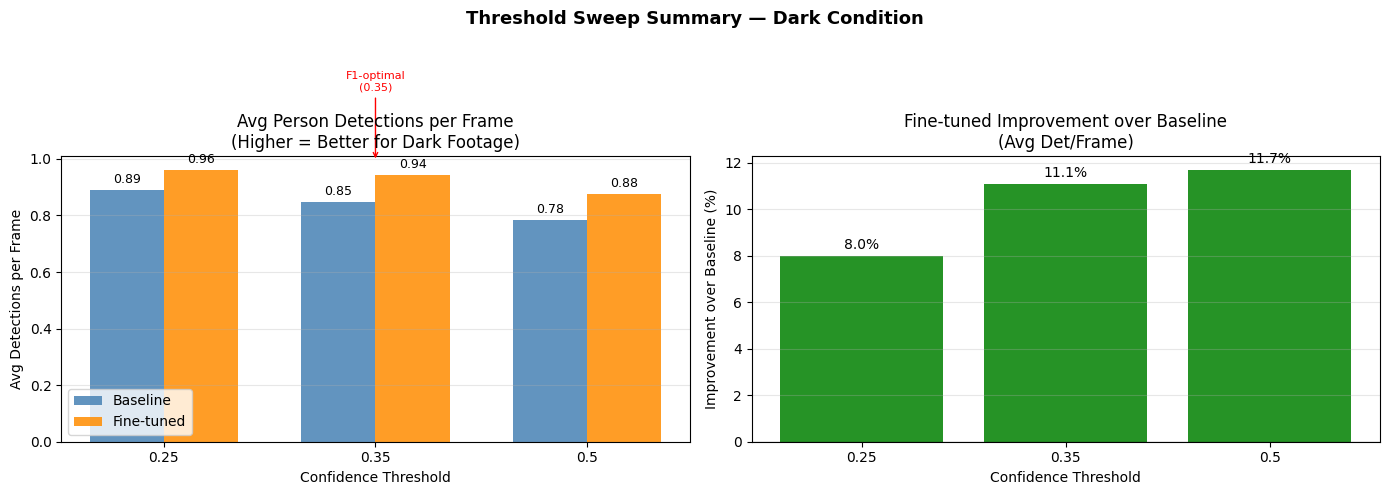

Saved bar chart to: outputs/dark_comparison\threshold_comparison_bars.png

>>> Recommended threshold for deployment: 0.5
    Improvement at this threshold: +11.7% avg detections


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Avg detections per frame ---
ax = axes[0]
x      = np.arange(len(THRESHOLDS))
width  = 0.35

avg_b = []
avg_f = []
for thresh in THRESHOLDS:
    rec_b, _ = results_store[thresh]['baseline']
    rec_f, _ = results_store[thresh]['finetuned']
    avg_b.append(np.mean([r['count'] for r in rec_b]))
    avg_f.append(np.mean([r['count'] for r in rec_f]))

bars_b = ax.bar(x - width/2, avg_b, width,
                label='Baseline', color='steelblue', alpha=0.85)
bars_f = ax.bar(x + width/2, avg_f, width,
                label='Fine-tuned', color='darkorange', alpha=0.85)

ax.bar_label(bars_b, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(bars_f, fmt='%.2f', padding=3, fontsize=9)
ax.set_xlabel('Confidence Threshold')
ax.set_ylabel('Avg Detections per Frame')
ax.set_title('Avg Person Detections per Frame\n(Higher = Better for Dark Footage)')
ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in THRESHOLDS])
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Annotate F1-optimal threshold
if 0.35 in THRESHOLDS:
    opt_idx = THRESHOLDS.index(0.35)
    ax.annotate('F1-optimal\n(0.35)',
                xy=(opt_idx, max(avg_b[opt_idx], avg_f[opt_idx]) + 0.05),
                ha='center', color='red', fontsize=8,
                arrowprops=dict(arrowstyle='->', color='red'),
                xytext=(opt_idx, max(avg_b[opt_idx], avg_f[opt_idx]) + 0.3))

# --- Right: Improvement % ---
ax2 = axes[1]
improvements = [
    round((f - b) / max(b, 1e-6) * 100, 1)
    for b, f in zip(avg_b, avg_f)
]
colors = ['green' if v >= 0 else 'red' for v in improvements]
bars = ax2.bar([str(t) for t in THRESHOLDS], improvements,
               color=colors, alpha=0.85)
ax2.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=10)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Confidence Threshold')
ax2.set_ylabel('Improvement over Baseline (%)')
ax2.set_title('Fine-tuned Improvement over Baseline\n(Avg Det/Frame)')
ax2.grid(axis='y', alpha=0.3)

plt.suptitle(
    'Threshold Sweep Summary — Dark Condition',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()

bar_path = os.path.join(OUTPUT_DIR, 'threshold_comparison_bars.png')
plt.savefig(bar_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved bar chart to:', bar_path)

# Print recommendation
best_thresh_idx = np.argmax(improvements)
best_thresh     = THRESHOLDS[best_thresh_idx]
print(f'\n>>> Recommended threshold for deployment: {best_thresh}')
print(f'    Improvement at this threshold: +{improvements[best_thresh_idx]:.1f}% avg detections')

## 8) Final Printed Report

Clean text summary suitable for copy-pasting directly into your FYP report.

In [9]:
print('=' * 60)
print('  DARK CONDITION EVALUATION SUMMARY')
print('  Baseline vs Fine-tuned (LLVIP Real Labels)')
print('=' * 60)
print(f'  Video : {os.path.basename(VIDEO_PATH)}')
print(f'  Frames: {len(frames_b)}')
print()

for thresh in THRESHOLDS:
    rec_b, _ = results_store[thresh]['baseline']
    rec_f, _ = results_store[thresh]['finetuned']
    cb = [r['count'] for r in rec_b]
    cf = [r['count'] for r in rec_f]
    imp = (np.mean(cf) - np.mean(cb)) / max(np.mean(cb), 1e-6) * 100
    miss_b = sum(1 for c in cb if c == 0)
    miss_f = sum(1 for c in cf if c == 0)

    marker = ' ◄ F1-optimal' if thresh == 0.35 else ''
    print(f'  Threshold = {thresh}{marker}')
    print(f'    Baseline   — avg: {np.mean(cb):.3f} det/frame | '
          f'zero-det frames: {miss_b} ({100*miss_b/len(cb):.1f}%)')
    print(f'    Fine-tuned — avg: {np.mean(cf):.3f} det/frame | '
          f'zero-det frames: {miss_f} ({100*miss_f/len(cf):.1f}%)')
    sign = '+' if imp >= 0 else ''
    print(f'    Improvement: {sign}{imp:.1f}%')
    print()

print('=' * 60)
print('  NOTE: Higher avg det/frame on dark footage indicates')
print('  the fine-tuned model recovers more persons that the')
print('  baseline misses due to low-light conditions.')
print('=' * 60)

  DARK CONDITION EVALUATION SUMMARY
  Baseline vs Fine-tuned (LLVIP Real Labels)
  Video : night.avi
  Frames: 565

  Threshold = 0.25
    Baseline   — avg: 0.890 det/frame | zero-det frames: 76 (13.5%)
    Fine-tuned — avg: 0.961 det/frame | zero-det frames: 34 (6.0%)
    Improvement: +8.0%

  Threshold = 0.35 ◄ F1-optimal
    Baseline   — avg: 0.848 det/frame | zero-det frames: 92 (16.3%)
    Fine-tuned — avg: 0.942 det/frame | zero-det frames: 42 (7.4%)
    Improvement: +11.1%

  Threshold = 0.5
    Baseline   — avg: 0.784 det/frame | zero-det frames: 123 (21.8%)
    Fine-tuned — avg: 0.876 det/frame | zero-det frames: 72 (12.7%)
    Improvement: +11.7%

  NOTE: Higher avg det/frame on dark footage indicates
  the fine-tuned model recovers more persons that the
  baseline misses due to low-light conditions.
